# 6. Modelado con PySpark ML

Se reutiliza la misma población elegible y la misma partición estratificada de la sección anterior. El entrenamiento está implementado en `run_spark_pipeline.py`: transforma numéricas y categóricas con `Imputer`, `StringIndexer`, `OneHotEncoder`, `VectorAssembler` y `StandardScaler`; después deja el `DataFrame` cacheado tras `VectorAssembler` y ajusta seis estimadores mediante `ParamGridBuilder` y `CrossValidator`. No se usa `toPandas` para la base: solo se materializan las predicciones de prueba, necesarias para las pruebas pareadas.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = PROJECT_DIR / 'results' / 'spark'
ART_DIR = PROJECT_DIR / 'artifacts' / 'spark'
models = ['logistic_regression', 'decision_tree', 'random_forest', 'gradient_boosted_tree', 'linear_svc', 'naive_bayes']
labels = {
    'logistic_regression': 'Regresión logística', 'decision_tree': 'Árbol de decisión',
    'random_forest': 'Bosque aleatorio', 'gradient_boosted_tree': 'GBT',
    'linear_svc': 'SVM lineal', 'naive_bayes': 'Naive Bayes gaussiano',
}
rows = []
for model in models:
    file = RESULTS_DIR / f'metrics_{model}.json'
    if file.exists():
        row = json.loads(file.read_text(encoding='utf-8'))
        row['nombre'] = labels[model]
        rows.append(row)
metrics_spark = pd.DataFrame(rows).set_index('model')
display(metrics_spark)
metrics_spark.to_csv(RESULTS_DIR / 'comparacion_metricas_spark.csv', encoding='utf-8-sig')

,n_test,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,fit_cv_seconds,predict_seconds,nombre
model,,,,,,,,,,,,,
logistic_regression,269062,0.802347,0.548958,0.055425,0.100685,0.709876,212904,2446,50735,2977,105.581931,6.633946,Regresión logística
decision_tree,269062,0.801358,0.517382,0.073429,0.128605,0.493899,211671,3679,49768,3944,52.095151,0.957293,Árbol de decisión
random_forest,269062,0.802094,0.556754,0.042281,0.078594,0.706750,213542,1808,51441,2271,398.522563,13.956101,Bosque aleatorio
gradient_boosted_tree,269062,0.802715,0.547340,0.067806,0.120664,0.712743,212338,3012,50070,3642,885.569881,13.819425,GBT
linear_svc,269062,0.800373,0.000000,0.000000,0.000000,0.630146,215350,0,53712,0,192.399239,6.400612,SVM lineal
naive_bayes,269062,0.667827,0.313167,0.556468,0.400783,0.525537,149798,65552,23823,29889,64.913019,7.647588,Naive Bayes gaussiano


En PySpark, el mayor AUC ROC corresponde a `GBTClassifier` (0,7127), seguido de regresión logística (0,7099) y bosque aleatorio (0,7068). La comparación se realiza sobre la misma prueba común y con el mismo criterio AUC; las diferencias de recall y F1 muestran que el umbral predeterminado produce comportamientos distintos frente a la clase minoritaria.

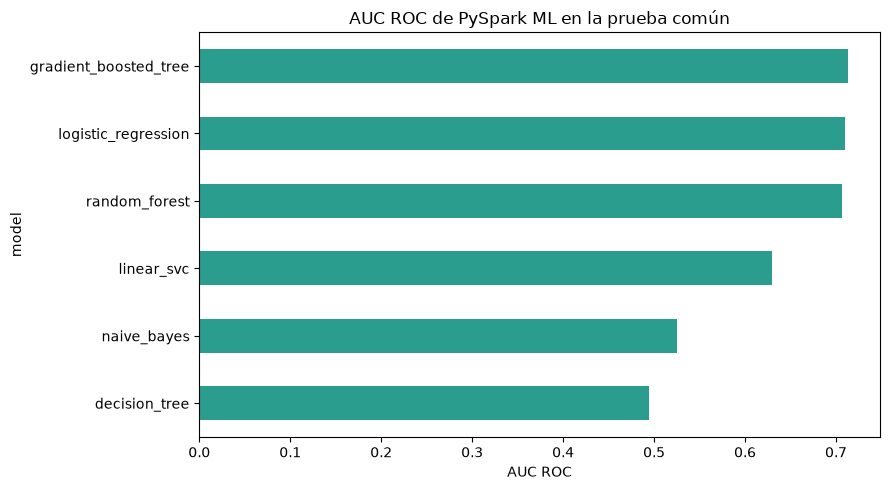

In [2]:
if len(metrics_spark):
    ax = metrics_spark['roc_auc'].sort_values().plot(kind='barh', figsize=(9, 5), color='#2a9d8f')
    ax.set_title('AUC ROC de PySpark ML en la prueba común')
    ax.set_xlabel('AUC ROC')
    fig = ax.get_figure(); fig.tight_layout(); fig.savefig(PROJECT_DIR / 'figures' / 'spark_auc.png', dpi=150); plt.show()

La ejecución se configuró con dos folds y grids reducidos para que el cálculo fuera viable en el equipo disponible; esto no modifica la población ni la partición. El bosque usa 10 árboles y el GBT 50 iteraciones, de forma análoga a las adaptaciones documentadas para scikit-learn. Spark se ejecuta con una ruta temporal corta (`C:\jtmp`) en Windows por el límite de rutas de sockets de Java.